In [1]:
# Import necessary packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import csv
import geopandas as gpd
import pylab 
import scipy.stats as stats
from scipy import ndimage
import gmaps 
import gmaps.datasets 
from datetime import datetime
from shapely.geometry import Point
import re

import folium
from folium.plugins import HeatMap

%matplotlib inline
sns.set()

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/folium/__init__.py:59: UserWarning: This version of folium is the last to support Python 2. Transition to Python 3 to be able to receive updates and fixes. Check out https://python3statement.org/ for more info.
  UserWarning


In [2]:
# Set the Filepath

points_file_path = "data/project/Israel_data_gis.csv"
 
FILE_NAME = "data/project/Hula_data_with_centroid.csv"
FILE_HEADER = ['project', 'grower', 'plot_name', 'report_date', 'crop', 'pest', 'data', 
               'latitude', 'longitude', 'plot_latitude', 'plot_longitude']
 
df = pd.read_csv(FILE_NAME)

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/IPython/core/interactiveshell.py:2714: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [3]:
# Data types for all columns/attributes
df.dtypes

project            object
grower             object
plot_name          object
report_date        object
crop               object
pest               object
data               object
latitude          float64
longitude         float64
plot_latitude     float64
plot_longitude    float64
dtype: object

In [4]:
# Let's see the raw data

df.head()

,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
0,Hula,Avney Eitan,Avney Eitan_103,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NaN,NaN,32.816108,35.759777
1,Hula,Avney Eitan,Avney Eitan_117,6/14/17 0:00,Plum,Medfly Trap Male,0,NaN,NaN,32.814104,35.762524
2,Hula,Avney Eitan,Avney Eitan_146,6/14/17 0:00,Pears,Medfly Trap Male,0,NaN,NaN,32.815617,35.765191
3,Hula,Avney Eitan,Avney Eitan_167,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NaN,NaN,32.814700,35.768080
4,Hula,Avney Eitan,Avney Eitan_204,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NaN,NaN,32.801553,35.781607


# Coordinate Cleaning

In [5]:
# Find all null coordinates and save their indexes

null_index = np.array(df[df['longitude'].isnull()].index)
nulls = df.loc[null_index, :]
num_nulls = len(nulls)
prop_nulls = num_nulls/len(df)
print("There are " + str(num_nulls) + " null coordinate pairs.")
nulls.head()

There are 269607 null coordinate pairs.


,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
0,Hula,Avney Eitan,Avney Eitan_103,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NaN,NaN,32.816108,35.759777
1,Hula,Avney Eitan,Avney Eitan_117,6/14/17 0:00,Plum,Medfly Trap Male,0,NaN,NaN,32.814104,35.762524
2,Hula,Avney Eitan,Avney Eitan_146,6/14/17 0:00,Pears,Medfly Trap Male,0,NaN,NaN,32.815617,35.765191
3,Hula,Avney Eitan,Avney Eitan_167,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NaN,NaN,32.814700,35.768080
4,Hula,Avney Eitan,Avney Eitan_204,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NaN,NaN,32.801553,35.781607


In [6]:
# Setting null point coordinates to the centroid of the respective plots that contains them.

lat = df['latitude'].values
lon = df['longitude'].values

plot_lat = df['plot_latitude'].values
plot_lon = df['plot_longitude'].values

for i in null_index:
    lat[i] = plot_lat[i]
    lon[i] = plot_lon[i]

df['latitude'] = lat
df['longitude'] = lon

In [7]:
df.head()

,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
0,Hula,Avney Eitan,Avney Eitan_103,6/14/17 0:00,Nectarine,Medfly Trap Male,0,32.816108,35.759777,32.816108,35.759777
1,Hula,Avney Eitan,Avney Eitan_117,6/14/17 0:00,Plum,Medfly Trap Male,0,32.814104,35.762524,32.814104,35.762524
2,Hula,Avney Eitan,Avney Eitan_146,6/14/17 0:00,Pears,Medfly Trap Male,0,32.815617,35.765191,32.815617,35.765191
3,Hula,Avney Eitan,Avney Eitan_167,6/14/17 0:00,Nectarine,Medfly Trap Male,0,32.814700,35.768080,32.814700,35.768080
4,Hula,Avney Eitan,Avney Eitan_204,6/14/17 0:00,Nectarine,Medfly Trap Male,0,32.801553,35.781607,32.801553,35.781607


# Date Cleaning

In [8]:
# Let's see the various lengths of all the dates
df.report_date.map(len).value_counts()

12    285294
11     97754
13     91412
14      4557
Name: report_date, dtype: int64

In [9]:
# Print out instances of each date length

print("All instances of date formats in the DataFrame:")
print("Length 11: " + df[(df['report_date'].map(len)) == 11].iloc[0]['report_date'])
print("Length 12: " + df[(df['report_date'].map(len)) == 12].iloc[0]['report_date'])
print("Length 13: " + df[(df['report_date'].map(len)) == 13].iloc[0]['report_date'])
print("Length 14: " + df[(df['report_date'].map(len)) == 14].iloc[0]['report_date'])

All instances of date formats in the DataFrame:
Length 11: 6/7/17 0:00
Length 12: 6/14/17 0:00
Length 13: 6/16/17 14:02
Length 14: 10/19/15 11:24


In [10]:
# Define a function to convert dates to a DateTime object. 
# This makes it easier for chronological filtering and analysis.

def convert_points(date):
    if date is None:
        return
    else:
        return datetime.strptime(date, '%m/%d/%y %H:%M')

In [11]:
# Apply the new function to the column.

df['report_date'] = df['report_date'].map(convert_points)

In [12]:
# Let's see the normalized report_date column

df.head()

,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
0,Hula,Avney Eitan,Avney Eitan_103,2017-06-14,Nectarine,Medfly Trap Male,0,32.816108,35.759777,32.816108,35.759777
1,Hula,Avney Eitan,Avney Eitan_117,2017-06-14,Plum,Medfly Trap Male,0,32.814104,35.762524,32.814104,35.762524
2,Hula,Avney Eitan,Avney Eitan_146,2017-06-14,Pears,Medfly Trap Male,0,32.815617,35.765191,32.815617,35.765191
3,Hula,Avney Eitan,Avney Eitan_167,2017-06-14,Nectarine,Medfly Trap Male,0,32.814700,35.768080,32.814700,35.768080
4,Hula,Avney Eitan,Avney Eitan_204,2017-06-14,Nectarine,Medfly Trap Male,0,32.801553,35.781607,32.801553,35.781607


# Crop Cleaning

In [13]:
# Display all the different crop types in our crop column and their respective frequencies

df['crop'].value_counts()

Apple                  200235
Pears                   61012
Plum                    53176
Peach                   40077
Nectarine               39262
Apricot                 25238
Cherries                15636
Peach and nectarine     14654
Pomegranate             12186
Citrus                   4931
Unrooted                 2562
Persimmon                2362
Golden                   1042
Citrus - traps            847
Quince                    771
Grapes                    608
Olives                    596
Deciduous - traps         560
Gala                      469
Figs                      442
Unknown                   386
Pink lady                 384
Wine Grapes               317
Granny Smith              300
Table Grapes              220
Starking                  180
Guayava                   106
Pecan                      89
Avocado                    78
Jonathan                   46
Ziziphus                   46
Lychee                     41
Blueberries                39
שייזף (x) 

In [14]:
# Since Olives appear in two different forms, we can convert them all to the same name.
# Since Undefined and Unknown crops are practically the same, we can normalize those as well.

df['crop'] = df['crop'].str.replace('Olives for oil', 'Olives')
df['crop'] = df['crop'].str.replace('Undefined', 'Unknown')

# Plot Name Cleaning

In [15]:
# Display the different plot names and their respective frequencies

df['plot_name'].value_counts()

15              588
42              583
54              561
19              552
51              548
16              510
53              486
120             481
52              477
31              469
122             459
121             458
61              455
12              447
57              446
60              438
132             436
21              434
32              433
55              429
34              422
14              421
17              421
40              420
64              417
45              408
24              401
128             400
22              397
114             395
               ... 
884002            1
133201            1
158502            1
1080              1
133203            1
K. Zvi_530        1
ביופיד חדש_1      1
ביופיד חדש_2      1
756-3 Jonath      1
Kfar Blum_10      1
769               1
102604            1
102603            1
2067              1
1904              1
821               1
750002            1
750003            1
946               1


In [16]:
#Counts of all the irregualr plot names (ones without numbers in them)

df[df['plot_name'].str.replace('(\D)', '').replace('', np.nan).fillna(0).astype(int) == 0]['plot_name'].value_counts()

תפוח                102
משמש                 92
עקור                 85
שזיף                 75
רימון                49
נקטרינה              37
אגס                  28
פקאן                 10
אפרסק                 6
אפרסמון               3
Undefined             3
Citrus Test Plot      2
Mishmesh bek          1
Afik mature           1
Sasa_00               1
Name: plot_name, dtype: int64

In [17]:
# Indices of irregular plot names from above

irregular_plot_names = df[df['plot_name'].str.replace('(\D)', '').replace('', np.nan).fillna(0).astype(int) == 0].index
irregular_plot_names

Int64Index([ 31970, 200819, 200820, 237284, 340054, 341304, 341321, 341663,
            343216, 343225,
            ...
            478398, 478558, 478699, 478703, 478704, 478705, 478913, 478992,
            479008, 479011],
           dtype='int64', length=495)

In [18]:
# Example of plot name without a number (can't really be used)

df[df['plot_name'] == "שזיף"].head()

,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
341304,Hula,Yesud HaMa'ala,שזיף,2016-08-04 07:57:00,Pomegranate,Medfly infection,0,33.070000,35.580000,33.073519,35.580406
406951,Hula,Yesud HaMa'ala,שזיף,2016-05-18 08:55:00,Apple,Medfly infection,0,33.047409,35.586671,33.047409,35.586671
407026,Hula,Yesud HaMa'ala,שזיף,2016-05-10 09:20:00,Pears,Medfly infection,0,33.067302,35.585466,33.067302,35.585466
407098,Hula,Yesud HaMa'ala,שזיף,2016-05-05 11:53:00,Pears,Medfly infection,0,33.067302,35.585466,33.067302,35.585466
408133,Hula,Yesud HaMa'ala,שזיף,2016-05-26 13:22:00,Plum,Medfly infection,0,33.020000,35.580000,33.049223,35.629555


In [19]:
# Since there aren't that many of these, let's drop all the rows with non-numeric or irregualr column names

df = df.drop(index=irregular_plot_names)

apple
armenian plum (mishmesh)
uprooting
plum
pomegrainate
nectarine
pear
pecan
peach
persimmon


In [20]:
# Convert all plot names to just the numbers they contain

df['plot_name'] = df['plot_name'].str.replace('(\D)', '').replace('', np.nan).astype(int)

In [21]:
# Notice the change in all the plot names to just integers. This makes analysis easier

df.head()

,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0,32.816108,35.759777,32.816108,35.759777
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0,32.814104,35.762524,32.814104,35.762524
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0,32.815617,35.765191,32.815617,35.765191
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0,32.814700,35.768080,32.814700,35.768080
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0,32.801553,35.781607,32.801553,35.781607


# Cleaning Infestation Data

In [22]:
# Since null data inputs are useless, we can drop them.

# We could save these points in a seperate DataFrame for the future so we could apply an
# interpolation method, such as Kriging or IDW in order to estimate the values of these points.

null_data = df[df['data'].isnull()].index
df = df.drop(null_data)

In [23]:
df['data'] = df['data'].astype(float)

In [24]:
max(df['data'].values)

10000.0

(array([4.77912e+05, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 3.00000e+00]),
 array([    0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,  7000.,
         8000.,  9000., 10000.]),
 <a list of 10 Patch objects>)

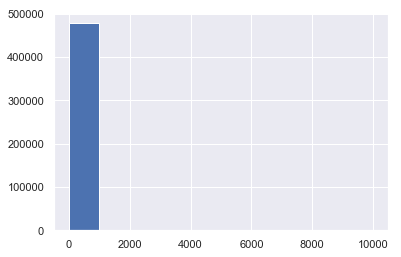

In [25]:
# Display a histrogram to visualize the ditribution of data values.
# From this we can see that there are some outliers above the more normal range of 0-10.

plt.hist(df['data'].values)

In [26]:
# How many outliers are there?

sum(df['data'] > 10)

3781

(array([4.63529e+05, 8.80100e+03, 2.39400e+03, 1.19300e+03, 4.51000e+02,
        4.32000e+02, 2.20000e+02, 2.67000e+02, 6.50000e+01, 1.25000e+02]),
 array([ 0.   ,  3.933,  7.866, 11.799, 15.732, 19.665, 23.598, 27.531,
        31.464, 35.397, 39.33 ]),
 <a list of 10 Patch objects>)

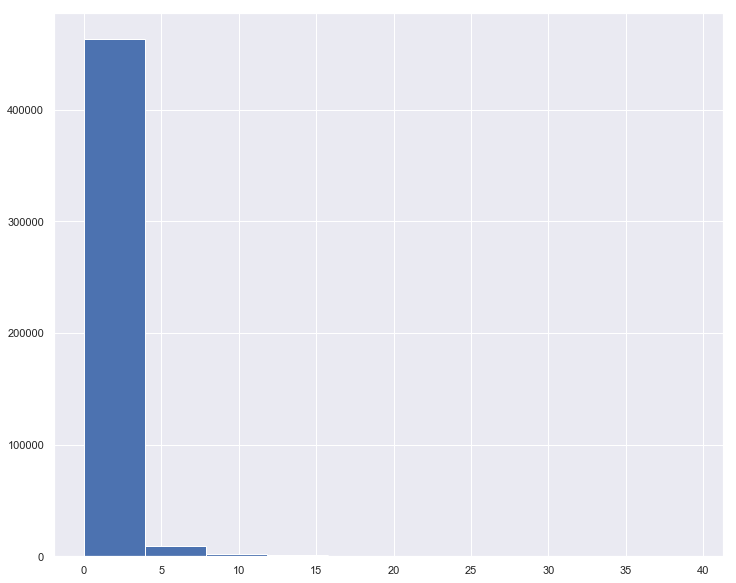

In [27]:
# Let's narrow down the window of points

plt.figure(figsize=(12,10))
plt.hist(df[df['data'] < 40]['data'].values)

In [28]:
# Remove all points with outlying values (we'll make our cutoff at 10)

df['data'] = df['data'].dropna().astype(float)
df = df[df['data'] <= 10]

(array([423910.,  22228.,  11563.,   5832.,   3592.,   2454.,   1387.,
          1371.,    908.,    892.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <a list of 10 Patch objects>)

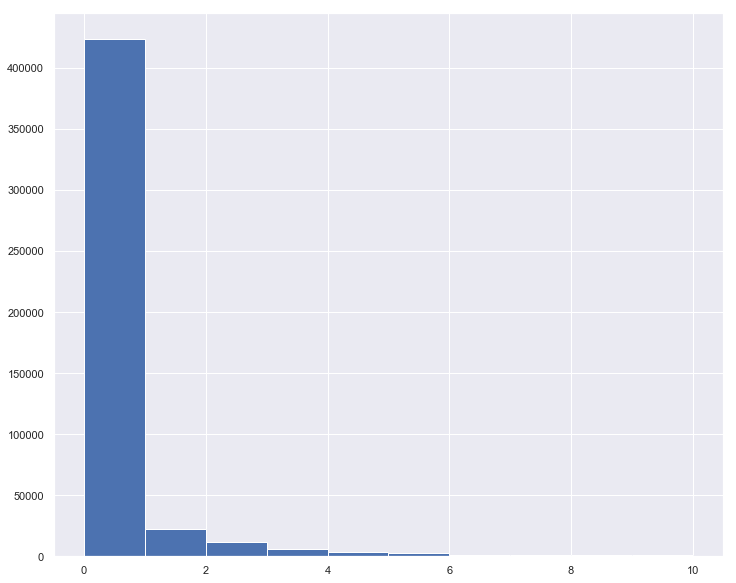

In [29]:
# Distribution of infestion data values after filtering out irregular values

plt.figure(figsize=(12,10))
plt.hist(df['data'].values)

In [30]:
# Most of the data seems to be under 2, but some high values still exist

over_6 = sum(df['data'] > 6)
print("There are " + str(over_6) + " points with an infestation rating over 6 ")

There are 3957 points with an infestation rating over 6 


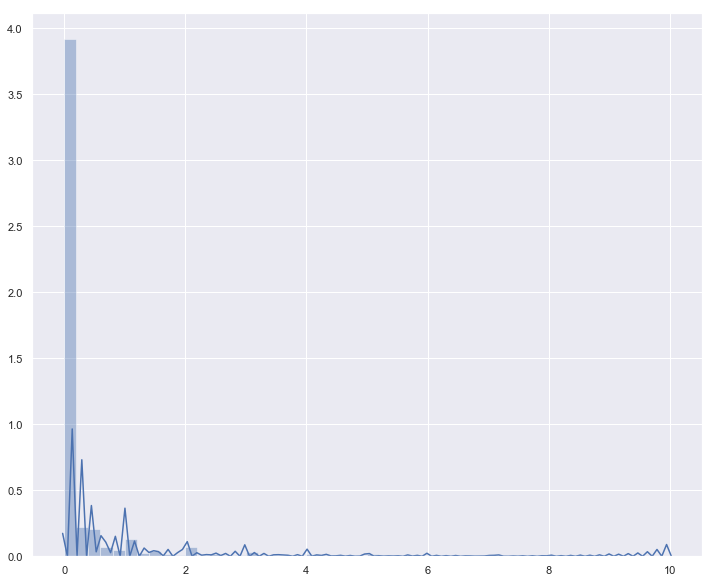

In [31]:
# Another way to look at it

plt.figure(figsize=(12,10))
sns.distplot(list(df['data'].values))

In [32]:
# Updated DataFrame
df.head()

,project,grower,plot_name,report_date,crop,pest,data,latitude,longitude,plot_latitude,plot_longitude
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,32.816108,35.759777,32.816108,35.759777
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,32.814104,35.762524,32.814104,35.762524
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,32.815617,35.765191,32.815617,35.765191
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,32.814700,35.768080,32.814700,35.768080
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,32.801553,35.781607,32.801553,35.781607


# Convert to GeoDataFrame

In [33]:
# Since most attributes have been cleaned, let's convert the DateFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude))

# After creating our geometry column with the coordinates, we can drop the unecessary columns 
gdf = gdf.drop(columns=['latitude', 'longitude', 'plot_latitude', 'plot_longitude'])

In [34]:
# Add individual columns for day, month, year, and week. This will make grouping by time more efficient.
gdf['day'] = gdf['report_date'].dt.day
gdf['month'] = gdf['report_date'].dt.month
gdf['year'] = gdf['report_date'].dt.year
gdf['week'] = gdf['report_date'].apply(lambda d: d.isocalendar()[1])

In [35]:
# The new GeoDataFrame is the same as the DataFrame before, but now with an active geometry column.
gdf.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.759777 32.816108),14,6,2017,24
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,POINT (35.76519099999999 32.815617),14,6,2017,24
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.76808 32.8147),14,6,2017,24
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.781607 32.80155300000001),14,6,2017,24


# Import the Plot Polygons

In [36]:
# Set the Filepath
plots_file_path = "data/project/plots/Medfly_plots.shp"

# Read the Data
plots = gpd.read_file(plots_file_path)

In [37]:
# Display the raw plots data
plots.head()

,Plot,Crop,Start,End,Grower,Group,Region,"Area, ha",Season yea,geometry
0,04 east,Maize/ Corn - Sweet Corn,15/04/2012 00:00,None,Yiron field crops,None,Hula,NaN,None,None
1,04 meshulashim,Maize/ Corn - Sweet Corn,9/4/12 0:00,None,Yiron field crops,None,Hula,NaN,None,None
2,1,Apple,None,None,Gamla,None,Golan,1.04,None,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,None,None,ניסוי מזרחיות,None,Valley south,NaN,None,None
4,1,Nectarine,2/1/19 0:00,None,Manara,None,Mountain,0.51,None,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


In [38]:
# Keep only the useful columns

plots = plots[['Plot', 'Crop', 'Grower', 'Region', 'geometry']]
plots.head()

,Plot,Crop,Grower,Region,geometry
0,04 east,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
1,04 meshulashim,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
2,1,Apple,Gamla,Golan,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,ניסוי מזרחיות,Valley south,None
4,1,Nectarine,Manara,Mountain,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


# Fix Column Names

In [39]:
# Convert all column names to lower case strings.
plots.columns = [str(n) for n in plots.columns]
plots.columns = map(str.lower, plots.columns)

# Change the name of the plots column to match our other data frame
plots = plots.rename({'plot': 'plot_name'}, axis=1)

In [40]:
plots.head()

,plot_name,crop,grower,region,geometry
0,04 east,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
1,04 meshulashim,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
2,1,Apple,Gamla,Golan,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,ניסוי מזרחיות,Valley south,None
4,1,Nectarine,Manara,Mountain,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


# Plot Cleaning

In [41]:
# Display names and frequencies of all plots
plots['plot_name'].value_counts()

עקור                  107
שזיף                   72
51                     61
53                     61
4                      59
22                     58
85                     57
2                      56
12                     56
24                     56
32                     54
9                      53
7                      53
16                     53
31                     52
11                     52
83                     52
6                      52
15                     51
25                     51
54                     51
תפוח                   50
10                     50
82                     50
1                      50
62                     50
19                     49
52                     49
104                    48
5                      48
                     ... 
148302                  1
901400                  1
148301                  1
22710                   1
BH313                   1
BH312                   1
Samech 2 Mizrach        1
Nectarina 13

In [42]:
# indices of irregular plot names from above which don't have numbers

missing_plots = plots[plots['plot_name'].str.replace('(\D)', '').replace('', np.nan).fillna(0).astype(int) == 0].index
missing_plots

Int64Index([27974, 27975, 27976, 27977, 27978, 27979, 27980, 27981, 27982,
            27983,
            ...
            29950, 29951, 29952, 29953, 29954, 29955, 29956, 29957, 29958,
            29959],
           dtype='int64', length=1025)

In [43]:
# let's drop all the rows with non-numerical column names
plots = plots.drop(index=missing_plots)

In [44]:
# Let's clean up the column by keeping only the numbers from each plot name and converting them to solid integers
plots['plot_name'] = plots['plot_name'].str.replace('(\D)', '').replace('', np.nan).astype(int)

In [45]:
plots.head()

,plot_name,crop,grower,region,geometry
0,4,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
1,4,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
2,1,Apple,Gamla,Golan,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,ניסוי מזרחיות,Valley south,None
4,1,Nectarine,Manara,Mountain,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


In [46]:
# Now let's see the frequencies of each plot
plots['plot_name'].value_counts()

1         180
2         177
3         169
4         154
7         105
8         102
6         102
5          99
12         87
10         76
9          75
34         74
11         68
32         64
51         63
31         63
15         63
22         62
53         62
13         62
16         61
33         60
24         60
85         57
19         55
14         54
25         54
54         53
17         52
78         52
         ... 
5135        1
81409       1
30136       1
46592       1
747002      1
491001      1
2090        1
577007      1
91089       1
81377       1
5302        1
91610       1
130002      1
722001      1
85439       1
3036        1
114001      1
110003      1
9650        1
153004      1
5087        1
812001      1
510002      1
85375       1
128003      1
91498       1
753001      1
46091       1
583002      1
48380       1
Name: plot_name, Length: 6461, dtype: int64

# Merging Point/Plot Dataframes

In [47]:
gdf.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.759777 32.816108),14,6,2017,24
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,POINT (35.76519099999999 32.815617),14,6,2017,24
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.76808 32.8147),14,6,2017,24
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.781607 32.80155300000001),14,6,2017,24


In [48]:
plots.head()

,plot_name,crop,grower,region,geometry
0,4,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
1,4,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
2,1,Apple,Gamla,Golan,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,ניסוי מזרחיות,Valley south,None
4,1,Nectarine,Manara,Mountain,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


In [49]:
# Since our points GeoDataFrame and plots DataFrame have the same column names, 
# we can merge them together on matching attributes, such as same grower, plot, and crop type.

data = pd.merge(gdf, plots, on=['grower', 'plot_name', 'crop'] , how='left')

In [50]:
# This made things a little messy, but nothing that can't be fixed
data.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry_x,day,month,year,week,region,geometry_y
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.759777 32.816108),14,6,2017,24,Golan,"POLYGON ((35.758851027 32.815719028, 35.759044..."
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24,Golan,"POLYGON ((35.7635644170001 32.812604982, 35.76..."
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,POINT (35.76519099999999 32.815617),14,6,2017,24,Golan,"POLYGON ((35.764772565 32.8159086140001, 35.76..."
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.76808 32.8147),14,6,2017,24,Golan,"POLYGON ((35.768792525 32.815524983, 35.769210..."
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.781607 32.80155300000001),14,6,2017,24,Golan,"POLYGON ((35.779937327 32.801546876, 35.781779..."


In [51]:
# Rename point and polygon columns
data = data.rename({"geometry_x": "geometry", "geometry_y": "geometry_plot"}, axis=1)

In [52]:
# Some plots may be null because there might not exist correspodning plots to some points, 
# so we drop those rows altogether.
data = data.dropna()

In [53]:
# Some plots may have been paired with points that they don't contain.
# We can fix that by removing all points that dont's lie within the plot coordinates they're paired with.

# Create a series of True/False values indicating whether a point lies within its plot
contains = data.apply(lambda row: row.geometry_plot.contains(row.geometry), axis=1)

# Keep only the rows fow which this is true
data = data[contains]

In [54]:
# Now we have all our data combined and can see each point with its corresponding plot that it lies within
data.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week,region,geometry_plot
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.759777 32.816108),14,6,2017,24,Golan,"POLYGON ((35.758851027 32.815719028, 35.759044..."
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24,Golan,"POLYGON ((35.7635644170001 32.812604982, 35.76..."
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,POINT (35.76519099999999 32.815617),14,6,2017,24,Golan,"POLYGON ((35.764772565 32.8159086140001, 35.76..."
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.76808 32.8147),14,6,2017,24,Golan,"POLYGON ((35.768792525 32.815524983, 35.769210..."
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.781607 32.80155300000001),14,6,2017,24,Golan,"POLYGON ((35.779937327 32.801546876, 35.781779..."


In [55]:
# Rename the newly created column
data = data.rename({'data_y': 'avg_infestation'}, axis=1)

# Final Clean DataFrame

In [56]:
data.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week,region,geometry_plot
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.759777 32.816108),14,6,2017,24,Golan,"POLYGON ((35.758851027 32.815719028, 35.759044..."
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24,Golan,"POLYGON ((35.7635644170001 32.812604982, 35.76..."
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,POINT (35.76519099999999 32.815617),14,6,2017,24,Golan,"POLYGON ((35.764772565 32.8159086140001, 35.76..."
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.76808 32.8147),14,6,2017,24,Golan,"POLYGON ((35.768792525 32.815524983, 35.769210..."
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.781607 32.80155300000001),14,6,2017,24,Golan,"POLYGON ((35.779937327 32.801546876, 35.781779..."


# Time and Space Data

In [57]:
#Individual dataframes based off year (however, this is repetitive and innefficient)
data_2009 = data[data['year'] == 2009]
data_2011 = data[data['year'] == 2011]
data_2012 = data[data['year'] == 2012]
data_2013 = data[data['year'] == 2013]
data_2014 = data[data['year'] == 2014]
data_2015 = data[data['year'] == 2015]
data_2016 = data[data['year'] == 2016]
data_2017 = data[data['year'] == 2017]
data_2018 = data[data['year'] == 2018]
data_2019 = data[data['year'] == 2019]

In [58]:
#Individual dataframes based off month (however, this is repetitive and innefficient)
data_Jan = data[data['month'] == 1]
data_Feb = data[data['month'] == 2]
data_Mar = data[data['month'] == 3]
data_Apr = data[data['month'] == 4]
data_May = data[data['month'] == 5]
data_Jun = data[data['month'] == 6]
data_Jul = data[data['month'] == 7]
data_Aug = data[data['month'] == 8]
data_Sep = data[data['month'] == 9]
data_Oct = data[data['month'] == 10]
data_Nov = data[data['month'] == 11]
data_Dec = data[data['month'] == 12]

# Filtering Functions

In [59]:
#Function that returns a new GeoDataFrame filtered by year input.
#EXAMPLE: data_year(2017) --> all data points recorded in year 2017

def data_year(df, year):
    return df[df['year'] == year]

In [60]:
#Function that returns a new GeoDataFrame filtered by month input.
#EXAMPLE: data_year(6) --> all data points recorded in month of June

def data_month(df, month):
    return df[df['month'] == month]

In [61]:
#Function that returns a new GeoDataFrame filtered by day input.
#EXAMPLE: data_day(18) --> all data points recorded on the 18th day of the month

def data_day(df, day):
    return df[df['day'] == day]

In [62]:
#Function that returns a new GeoDataFrame filtered by week input.
#EXAMPLE: data_week(9) --> all data points recorded on the 9th week of the year

def data_week(df, week):
    return df[df['week'] == week]

In [63]:
#Function that returns a new dataframe filtered by crop type.
#EXAMPLE: data_year('apple') --> all data points recorded for apples

def data_crop(df, crop):
    return df[df['crop'] == crop]

In [64]:
#Function that returns a new dataframe filtered by region.
#EXAMPLE: data_region('Golan') --> all data points in Golan

def data_region(df, region):
    return df[df['region'] == region]

In [65]:
#Function that returns a new dataframe filtered by region.
#EXAMPLE: data_region('Avney Eitan') --> all data points from Avney Eitan

def data_grower(df, grower):
    return df[df['grower'] == grower]

In [67]:
# Using the functions we just creatednstead we can do something like this ...

#Create GeoDataFrames for seperate years
data_2015 = data_year(data, 2015)
data_2016 = data_year(data, 2016)
data_2017 = data_year(data, 2017)
data_2018 = data_year(data, 2018)


In [68]:
#Use the newly-created year dataframes to select by region
golan_2015 = data_region(data_2015, 'Golan')
golan_2016 = data_region(data_2016, 'Golan')
golan_2017 = data_region(data_2017, 'Golan')
golan_2018 = data_region(data_2018, 'Golan')

In [69]:
months = range(1,13)

In [75]:
data.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week,region,geometry_plot
0,Hula,Avney Eitan,103,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.759777 32.816108),14,6,2017,24,Golan,"POLYGON ((35.758851027 32.815719028, 35.759044..."
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24,Golan,"POLYGON ((35.7635644170001 32.812604982, 35.76..."
2,Hula,Avney Eitan,146,2017-06-14,Pears,Medfly Trap Male,0.0,POINT (35.76519099999999 32.815617),14,6,2017,24,Golan,"POLYGON ((35.764772565 32.8159086140001, 35.76..."
3,Hula,Avney Eitan,167,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.76808 32.8147),14,6,2017,24,Golan,"POLYGON ((35.768792525 32.815524983, 35.769210..."
4,Hula,Avney Eitan,204,2017-06-14,Nectarine,Medfly Trap Male,0.0,POINT (35.781607 32.80155300000001),14,6,2017,24,Golan,"POLYGON ((35.779937327 32.801546876, 35.781779..."


In [ ]:
# Calcualte the average infestation from all points in each plot respectively and add the values as a column.
    def avg_infestation(row):
    row['geometry_plot']
    avg_infestation = p.groupby('plot_name').mean()['data'].reset_index()
    p = p.merge(avg_infestation, on='plot_name')

In [98]:
everything = data.groupby(['region', 'year', 'month', 'plot_name']).mean()
everything

data        day   week
region       year month plot_name                          
Golan        2012 5     566        0.0000  28.000000  22.00
                        1497       0.0000  28.000000  22.00
                        3082       0.0700  24.000000  21.00
                        3204       0.0000  16.750000  19.75
                  6     135        0.0000  25.000000  26.00
                        566        0.0000  13.500000  23.50
                        688        0.0000  16.000000  24.50
                        689        0.0000  16.000000  24.50
                        690        0.0000  16.000000  24.50
                        691        0.0000  16.500000  24.50
                        926        0.0000   5.000000  23.00
                        1497       0.0000  13.500000  23.50
                        1661       0.0000  16.250000  24.50
                        1662       0.0000  14.200000  24.20
                        1663       0.0000  16.250000  24.50
                        1668       0.0000  16.250000  24.50
                        1669       0.0000  16.250000  24.50
                        1671       0.0000  16.250000  24.50
                        1672       0.0000  16.250000  24.50
                        2877       0.0000  16.250000  24.50
                        3063       0.0000  26.000000  26.00
                        3064       0.0000  26.000000  26.00
                        3082       0.0525  14.750000  24.00
                        3087       0.0000  26.000000  26.00
                        3088       0.0000  26.000000  26.00
                        3089       0.0280  16.000000  24.00
                        3101       0.0000  16.000000  24.50
                        3102       0.0000  19.333333  25.00
                        3103       0.0000  23.000000  25.50
                        3104       0.0000  16.500000  24.50
...                                   ...        ...    ...
Valley south 2019 6     601        0.0000   2.000000  22.00
                        603        0.0000   2.000000  22.00
                        669        0.0000   2.000000  22.00
                        705        0.0000   4.000000  23.00
                        718        0.0000   2.000000  22.00
                        726        0.0000   2.000000  22.00
                        729        0.0000   2.000000  22.00
                        751        0.0000   2.000000  22.00
                        765        0.0000   2.000000  22.00
                        793        0.0000   2.000000  22.00
                        1281       0.0000   4.000000  23.00
                        1336       0.0000   4.000000  23.00
                        1433       0.0000   3.000000  23.00
                        1437       0.0000   3.000000  23.00
                        1456       0.0000   3.000000  23.00
                        1469       0.0000   3.000000  23.00
                        1476       0.0000   5.000000  23.00
                        1484       0.0000   5.000000  23.00
                        1488       0.0000   5.000000  23.00
                        1491       0.0000   5.000000  23.00
                        1505       0.0000   3.000000  23.00
                        1507       0.0000   3.000000  23.00
                        1519       0.0000   4.000000  23.00
                        1531       0.0000   4.000000  23.00
                        1572       3.0000   5.000000  23.00
                        1578       0.0000   5.000000  23.00
                        2064       0.0000   5.000000  23.00
                        2073       0.0000   4.000000  23.00
                        2084       0.0000   4.000000  23.00
                        2088       0.0000   4.000000  23.00

[52859 rows x 3 columns]

In [ ]:
(region='Golan', year=[2017, 2018, 2019], plots=month)

In [ ]:
def sort_data(region=None, year=None, month=None, day=None, grower=None, crop=None):
    

In [93]:
g_2012 = everything.loc[('Golan', 2012)]

g_2012

data        day       week
month plot_name                                
5     566        0.000000  28.000000  22.000000
      1497       0.000000  28.000000  22.000000
      3082       0.070000  24.000000  21.000000
      3204       0.000000  16.750000  19.750000
6     135        0.000000  25.000000  26.000000
      566        0.000000  13.500000  23.500000
      688        0.000000  16.000000  24.500000
      689        0.000000  16.000000  24.500000
      690        0.000000  16.000000  24.500000
      691        0.000000  16.500000  24.500000
      926        0.000000   5.000000  23.000000
      1497       0.000000  13.500000  23.500000
      1661       0.000000  16.250000  24.500000
      1662       0.000000  14.200000  24.200000
      1663       0.000000  16.250000  24.500000
      1668       0.000000  16.250000  24.500000
      1669       0.000000  16.250000  24.500000
      1671       0.000000  16.250000  24.500000
      1672       0.000000  16.250000  24.500000
      2877       0.000000  16.250000  24.500000
      3063       0.000000  26.000000  26.000000
      3064       0.000000  26.000000  26.000000
      3082       0.052500  14.750000  24.000000
      3087       0.000000  26.000000  26.000000
      3088       0.000000  26.000000  26.000000
      3089       0.028000  16.000000  24.000000
      3101       0.000000  16.000000  24.500000
      3102       0.000000  19.333333  25.000000
      3103       0.000000  23.000000  25.500000
      3104       0.000000  16.500000  24.500000
...                   ...        ...        ...
11    4375       2.476667  15.666667  45.666667
      4378       3.286667  15.666667  45.666667
      4379       1.107500  15.000000  45.750000
      4380       0.462500  15.000000  45.750000
      4392       1.427500  15.000000  45.750000
      5403       0.285000  21.500000  46.500000
      5414       5.677500  15.000000  45.750000
12    566        0.070000  12.500000  49.500000
      3082       0.142500  12.500000  49.500000
      3089       2.190000  13.666667  49.666667
      3148       0.000000  19.500000  50.500000
      3150       0.000000  16.000000  50.000000
      3154       1.810000  16.000000  50.000000
      3157       1.380000  16.000000  50.000000
      3160       0.236667  16.000000  50.000000
      3172       0.190000  16.000000  50.000000
      3173       0.856667  16.000000  50.000000
      3178       0.046667  16.000000  50.000000
      3182       0.107500  19.500000  50.500000
      3204       1.000000   3.000000  49.000000
      3210       0.070000  19.500000  50.500000
      3230       0.177500  19.500000  50.500000
      3305       1.616667  16.000000  50.000000
      4375       0.236667  16.000000  50.000000
      4378       0.190000  16.000000  50.000000
      4379       0.046667  16.000000  50.000000
      4380       0.000000  19.500000  50.500000
      4392       0.000000  16.000000  50.000000
      5403       0.190000  16.000000  50.000000
      5414       0.570000  16.000000  50.000000

[401 rows x 3 columns]

In [95]:
plots['']

,plot_name,crop,grower,region,geometry
0,4,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
1,4,Maize/ Corn - Sweet Corn,Yiron field crops,Hula,None
2,1,Apple,Gamla,Golan,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,ניסוי מזרחיות,Valley south,None
4,1,Nectarine,Manara,Mountain,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


In [94]:
# Using the functions we just creatednstead we can do something like this ...

#Create GeoDataFrames for seperate years
data_2015 = data_year(data, 2015)
data_2016 = data_year(data, 2016)
data_2017 = data_year(data, 2017)
data_2018 = data_year(data, 2018)

#Use the newly-created year dataframes to select by region
golan_2015 = data_region(data_2015, 'Golan')
golan_2016 = data_region(data_2016, 'Golan')
golan_2017 = data_region(data_2017, 'Golan')
golan_2018 = data_region(data_2018, 'Golan')

#Or just selct one region by all years, but one crop
data_golan = data_region(data, 'Mountain')
golan_apples = data_crop(data_golan, 'Apple')

In [101]:
# Make a GeoDataFrame of just the plots
def data_plots(df):
    p = df.drop('geometry', axis=1).rename({'geometry_plot': 'geometry'}, axis=1)
    
    # Calcualte the average infestation from all points in each plot respectively and add the values as a column.
    avg_infestation = p.groupby('plot_name').mean()['data'].reset_index()
    p = p.merge(avg_infestation, on='plot_name')

In [102]:
# All the plots
all_plots = data_plots(data)

# Seperating plot datasets by Time and Space
plots_golan_2015 = data_plots(golan_2015)
plots_golan_2016 = data_plots(golan_2016)
plots_golan_2017 = data_plots(golan_2017)
plots_golan_2018 = data_plots(golan_2018)

KeyError: 'data'

In [99]:
# Find all the plots in the Golan and plot them on a map
plots_golan = data_region(data_plots, 'Golan')
plots_golan.plot(figsize=(20,15), color='red')

TypeError: 'function' object has no attribute '__getitem__'

In [ ]:
fig, ax = plt.subplots(1, figsize=(30,20))
plots_golan.plot(ax=ax, column='avg_infestation', markersize=0.01, legend=True, cmap='viridis_r')
plt.axis([35.6,35.9,32.7,33.3])
plt.show();

In [ ]:
# Visualize the distribution of average infections for plots
plt.hist(plots_golan.avg_infestation.values)

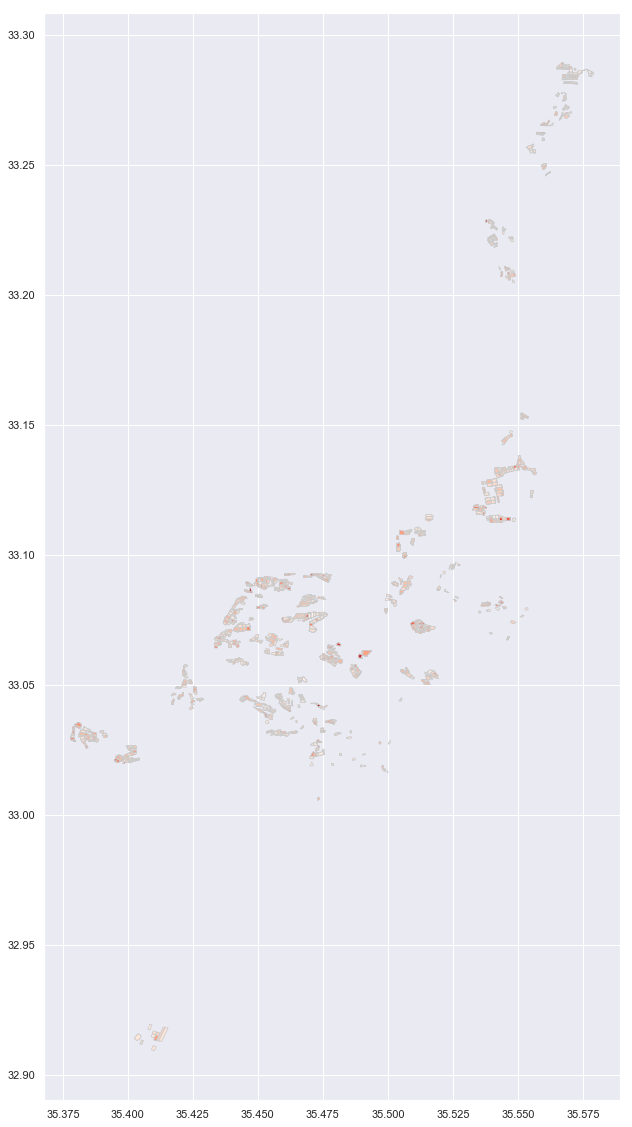

In [100]:
# set a variable that will call whatever column we want to visualise on the map
variable = 'avg_infestation'
# set the range for the choropleth
vmin, vmax = 0, 0.5
# create figure and axes for Matplotlib
fig, ax = plt.subplots(1, figsize=(30, 20))

# create map
plots_golan_2015.plot(column=variable, cmap='Reds', linewidth=0.8, ax=ax, edgecolor='0.8')

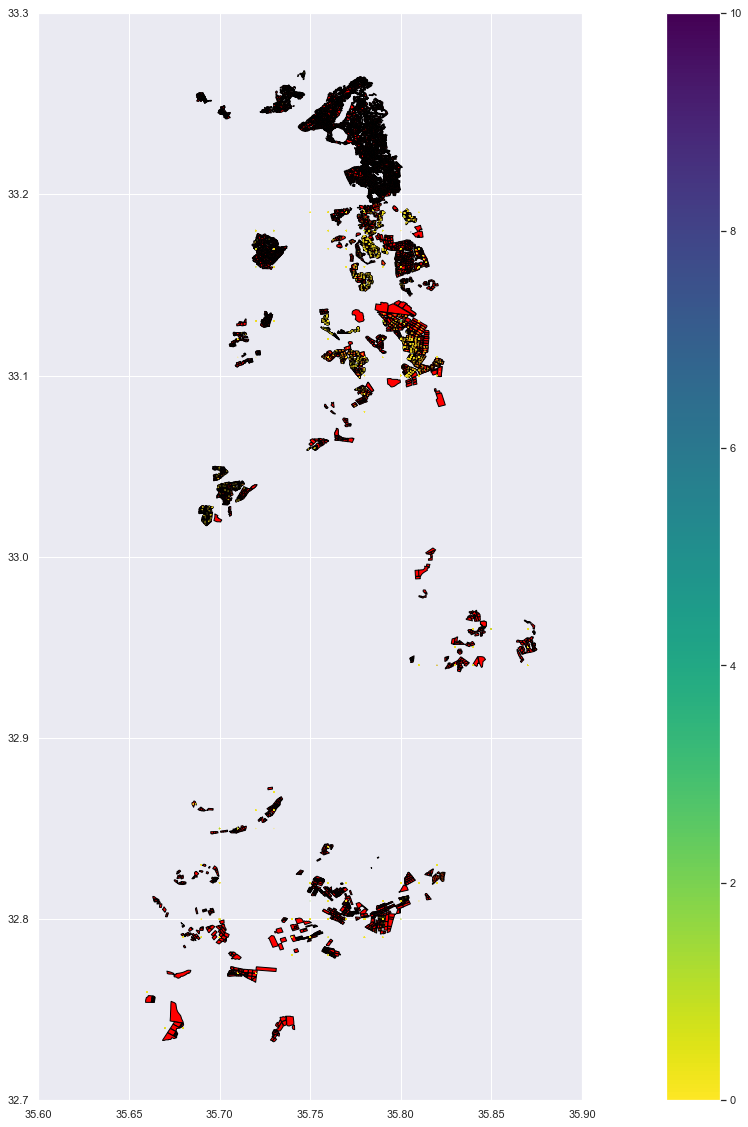

In [82]:
fig, ax = plt.subplots(1, figsize=(30,20))
base = plots_golan.plot(ax=ax, color='white', edgecolor='black')
golan_2015.plot(ax=base, column='data', markersize=0.01, legend=True, cmap='viridis_r')
plt.axis([35.6,35.9,32.7,33.3])
plt.show();

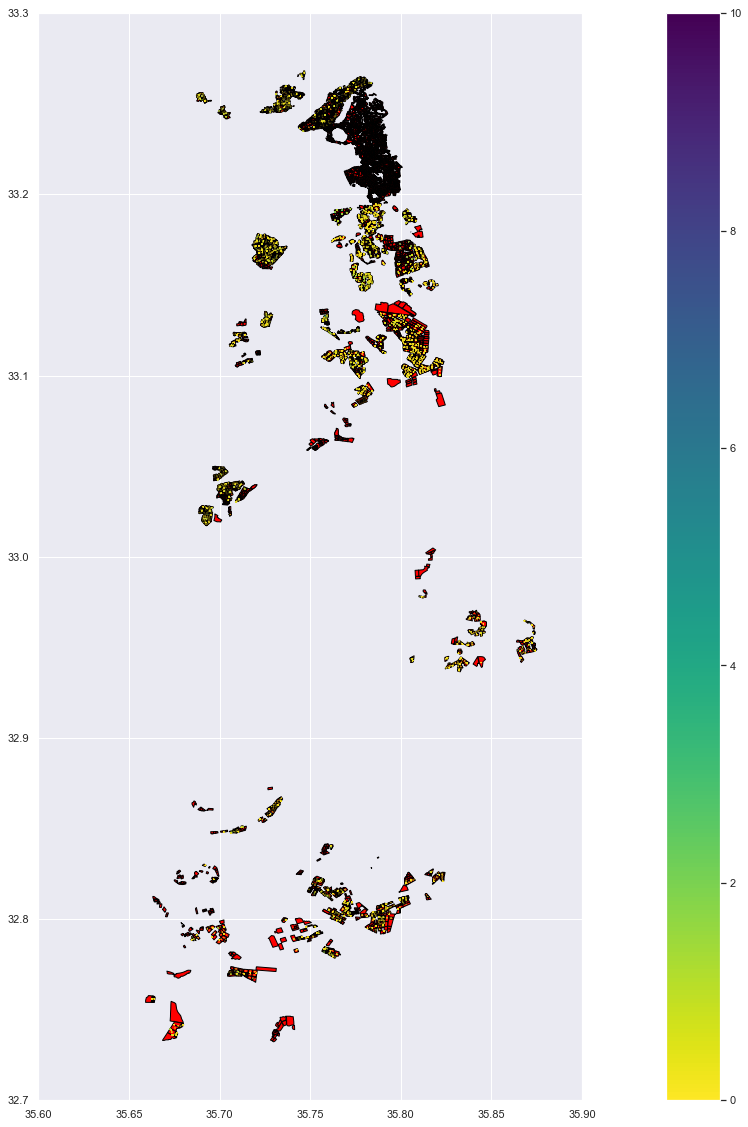

In [83]:
fig, ax = plt.subplots(1, figsize=(30,20))
base = plots_golan.plot(ax=ax, color='red', edgecolor='black')
golan_2016.plot(ax=base, column='data', markersize=0.01, legend=True, cmap='viridis_r')
plt.axis([35.6,35.9,32.7,33.3])
plt.show();

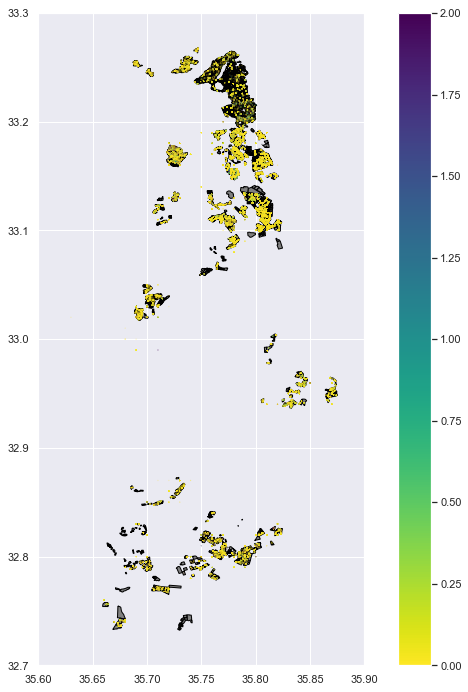

In [77]:
golan_2015 = data_year(data_golan, 2015)
golan_2016 = data_year(data_golan, 2016)
golan_2017 = data_year(data_golan, 2017)
golan_2018 = data_year(data_golan, 2018)

fig, ax = plt.subplots(1, figsize=(12,12))
plots_golan.plot(ax=ax, color='gray', edgecolor='black')
data_golan.plot(ax=ax, column='data', vmax=2, markersize=0.01, legend=True, cmap='viridis_r')
plt.axis([35.6,35.9,32.7,33.3])
plt.show();

# Analysis Between Days, Months, Years

In [344]:
data[data['data'].isnull()]

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week,region,geometry_plot
18796,Hula,Ortal,540,2014-07-26 06:25:00,Apple,Medfly Trap Male,NaN,POINT (35.779342 33.147892),26,7,2014,30,NaN,NaN
18805,Hula,Avivim,158,2015-04-07 09:39:00,Apple,Medfly Trap Male,NaN,POINT (35.476992 33.091915),7,4,2015,15,Mountain,"POLYGON ((35.47679279030589 33.09176638812352,..."
20702,Hula,Ortal,525,2013-05-05 00:00:00,Apple,Medfly Trap Male,NaN,POINT (35.773305 33.155911),5,5,2013,18,NaN,NaN
66390,Hula,Ortal,531,2014-07-26 06:25:00,Apple,Medfly Trap Male,NaN,POINT (35.776104 33.154598),26,7,2014,30,NaN,NaN
74879,Hula,Yesud HaMa'ala 2014,1107,2014-06-18 12:21:00,Apple,Medfly Trap Male,NaN,POINT (35.572915 33.045576),18,6,2014,25,Valley south,"POLYGON ((35.57301460200006 33.04464728100004,..."
87169,Hula,Yesud HaMa'ala_2015,7,2015-06-03 22:35:00,Pomegranate,Medfly Trap Male,NaN,POINT (35.603846 33.05315),3,6,2015,23,NaN,NaN
87170,Hula,Yesud HaMa'ala_2015,5,2015-06-03 22:35:00,Plum,Medfly Trap Male,NaN,POINT (35.598606 33.058359),3,6,2015,23,NaN,NaN
87171,Hula,Yesud HaMa'ala_2015,4,2015-06-03 22:35:00,Plum,Medfly Trap Male,NaN,POINT (35.602947 33.059863),3,6,2015,23,NaN,NaN
87172,Hula,Yesud HaMa'ala_2015,1,2015-06-03 22:35:00,Plum,Medfly Trap Male,NaN,POINT (35.598926 33.053907),3,6,2015,23,Valley south,"POLYGON ((35.56952830900008 33.03564350900007,..."
87173,Hula,Yesud HaMa'ala_2015,2,2015-06-03 22:35:00,Apple,Medfly Trap Male,NaN,POINT (35.601106 33.054801),3,6,2015,23,NaN,NaN


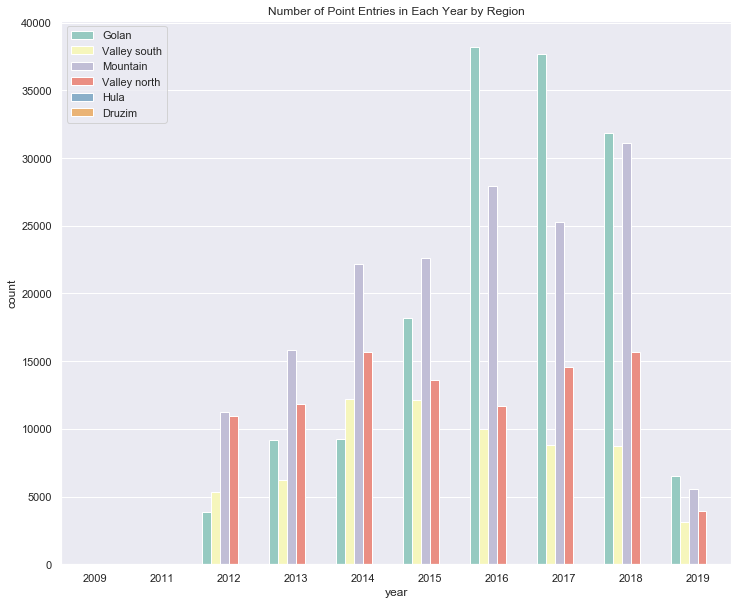

In [226]:
# Bar chart of number of point entries in each year categorized by region
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="year", data=data, hue='region', palette='Set3')
ax.set_title("Number of Point Entries in Each Year by Region")
plt.legend(loc='upper left')

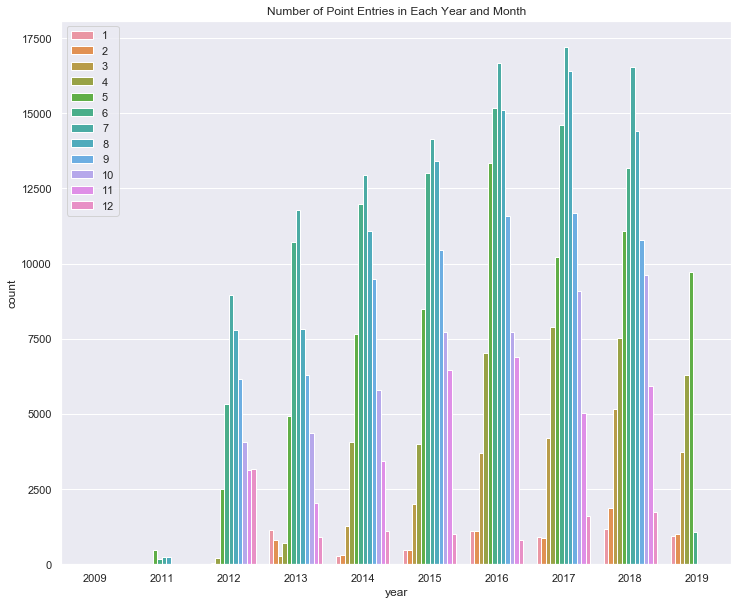

In [227]:
# Bar chart of number of point entries in each year and month
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="year", data=data, hue='month')
ax.set_title("Number of Point Entries in Each Year and Month")
plt.legend(loc='upper left')

In [281]:
data['data'].round().astype(int)

ValueError: Cannot convert non-finite values (NA or inf) to integer

(array([501255.,  26987.,  13995.,   7198.,   4383.,   2997.,   1737.,
          1638.,   1067.,    502.]),
 array([0.   , 0.993, 1.986, 2.979, 3.972, 4.965, 5.958, 6.951, 7.944,
        8.937, 9.93 ]),
 <a list of 10 Patch objects>)

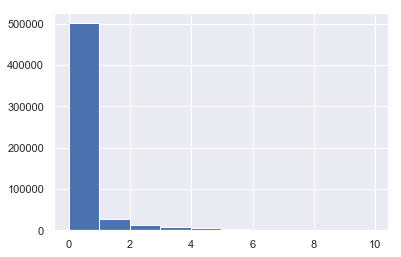

In [371]:
non_nulls = data['data'].dropna().astype(float)
plt.hist(non_nulls[non_nulls < 10].values)

ValueError: Cannot convert non-finite values (NA or inf) to integer

ValueError: cannot convert float NaN to integer

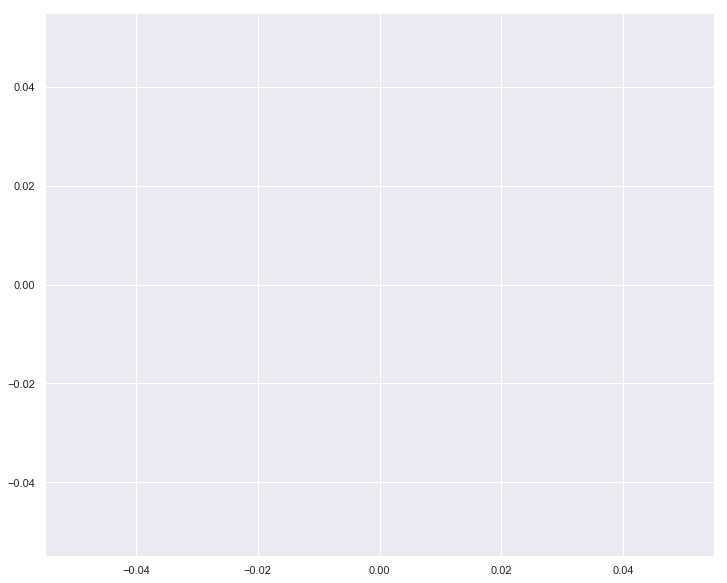

In [275]:
# Distribution of Weeks by number of point entries
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.distplot(data['data'])


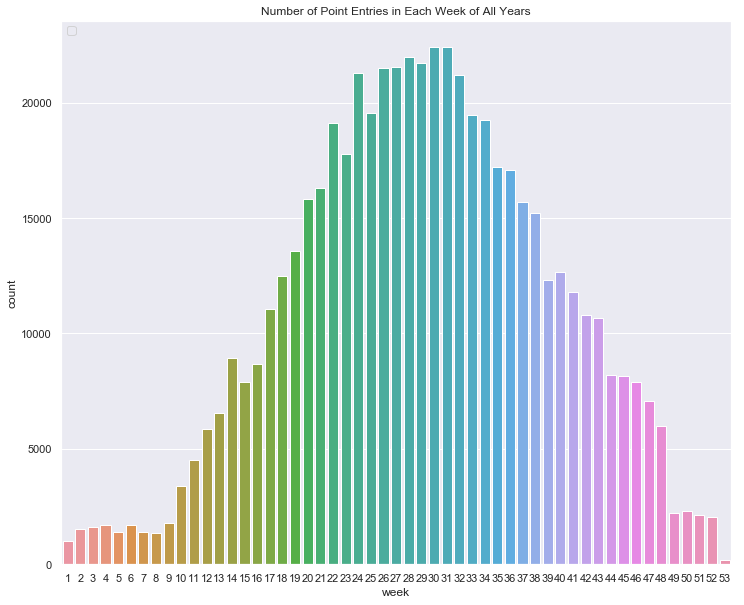

In [228]:
# Distribution of Weeks by number of point entries
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="week", data=data)
ax.set_title("Number of Point Entries in Each Week of All Years")
plt.legend(loc='upper left')

In [229]:
sd = np.std(data['week'])
mean = np.mean(data['week'])
high = mean + sd
low = mean - sd
middle_sd = data[(data['week'] >= low) & (data['week'] <= high)]
perc = float(len(middle_sd)) / float(len(data['week'])) * 100

print(str(perc) + "% of the data lies within 1 Standard Deviation of the mean (" + str(mean) + ")")
print("This is means that it follows a fairly normal distribution, as seen above.")

66.7623619644% of the data lies within 1 Standard Deviation of the mean (29.074503107)
This is means that it follows a fairly normal distribution, as seen above.


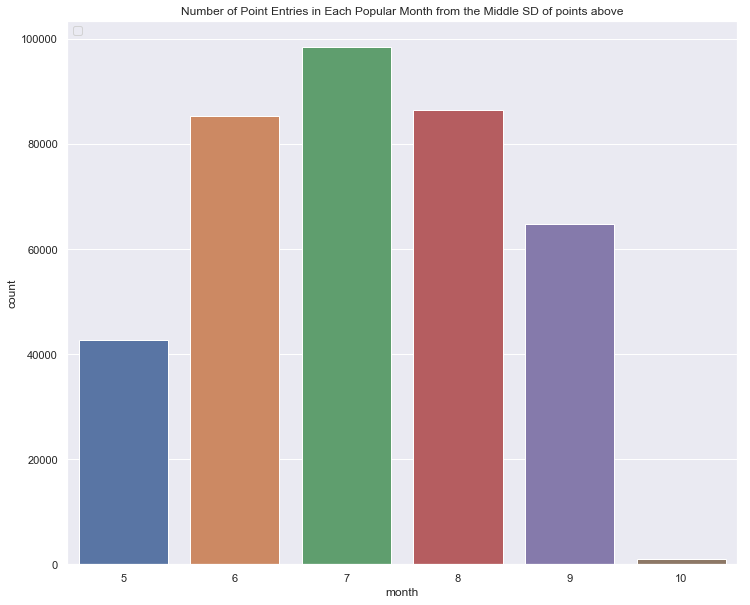

In [232]:
# Distribution of entries in popular months (summer)
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="month", data=middle_sd)
ax.set_title("Number of Point Entries in Each Popular Month from the Middle SD of points above")
plt.legend(loc='upper left')


AttributeError: Unknown property markeredgecolor

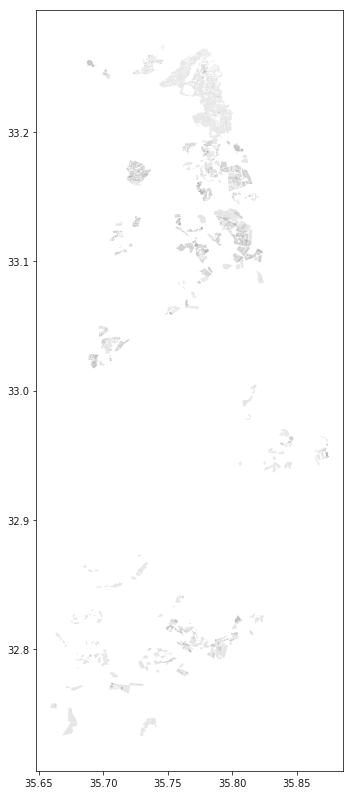

In [252]:
#Plotting location of all banks in Lima
plt.style.use("default")
%matplotlib inline
fig, ax = plt.subplots(1, figsize=(7, 14))
base = plots[plots['region'] == 'Golan'].plot(ax=ax, color='gray', alpha=0.2)
data_2017.plot(ax=base, marker="o", mfc="yellow", markersize=5, markeredgecolor="black", zorder=0)
_ = ax.axis('off')
ax.set_title("Plot of banks in Lima")

<Figure size 864x720 with 0 Axes>

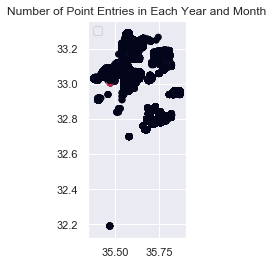

In [251]:
# Bar chart of number of point entries in each year and month
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = data_2015.plot(column='data')
ax.set_title("Number of Point Entries in Each Year and Month")
plt.legend(loc='upper left')



In [ ]:
plt.figure()

for i in range(1:13):
    plt.subplot(3,4,i)

In [247]:
range(1,13)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

ValueError: too many values to unpack

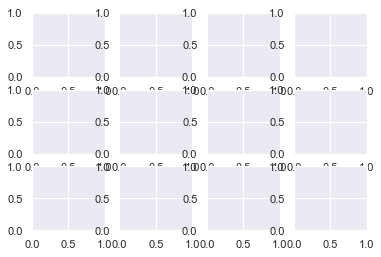

In [249]:
f, axes = plt.subplots(nrows=3, ncols=4)
for ax, month in axes.flatten(), range(1,13):
    ax = data_2017[data_2017['month'] == month].plot(ax=ax, column='data', markersize=0.01, vmax=100000, legend=True, cmap='RdYlGn')
    #lims = plt.axis('equal')

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/geopandas/plotting.py:418: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  "empty. Nothing has been displayed.", UserWarning)
/Users/rosskalter/anaconda2/lib/python2.7/site-packages/geopandas/plotting.py:418: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  "empty. Nothing has been displayed.", UserWarning)
/Users/rosskalter/anaconda2/lib/python2.7/site-packages/geopandas/plotting.py:418: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  "empty. Nothing has been displayed.", UserWarning)
/Users/rosskalter/anaconda2/lib/python2.7/site-packages/geopandas/plotting.py:418: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  "empty. Nothing has been displayed.", UserWarning)
/Users/rosskalter/anaconda2/lib/python2.7/site-packages/geopandas/plotting.p

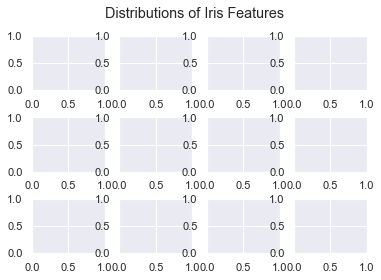

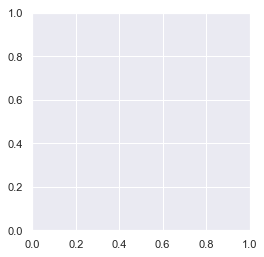

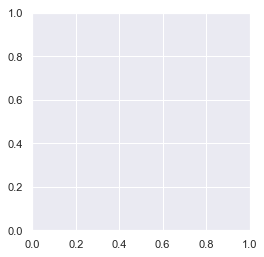

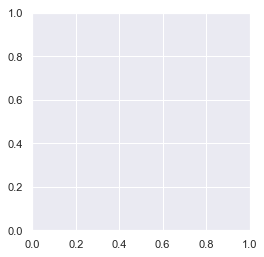

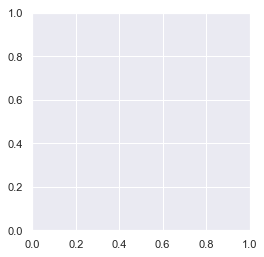

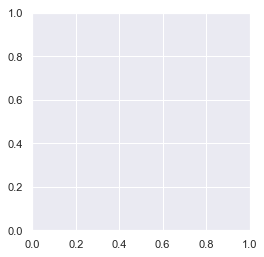

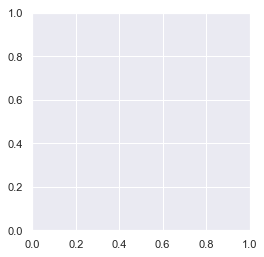

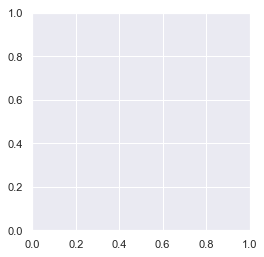

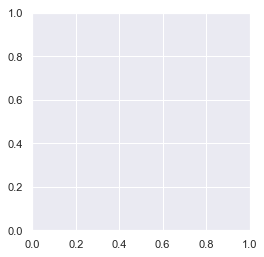

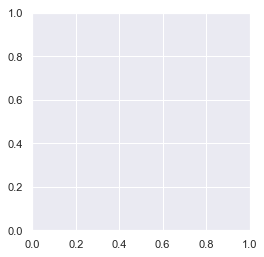

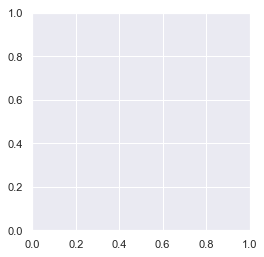

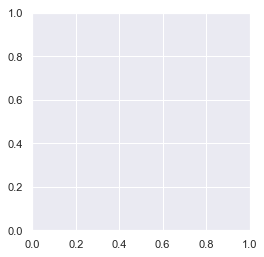

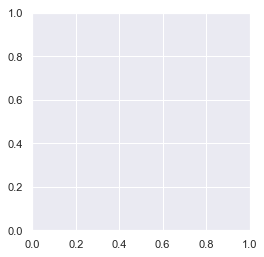

In [239]:
fig, axes = plt.subplots(nrows=3, ncols=4)

fig.suptitle('Distributions of Iris Features')

for ax in axes.flatten():
    ax = data_2015[data_2015['month'] == ax].plot()


ValueError: Axes instance argument was not found in a figure.

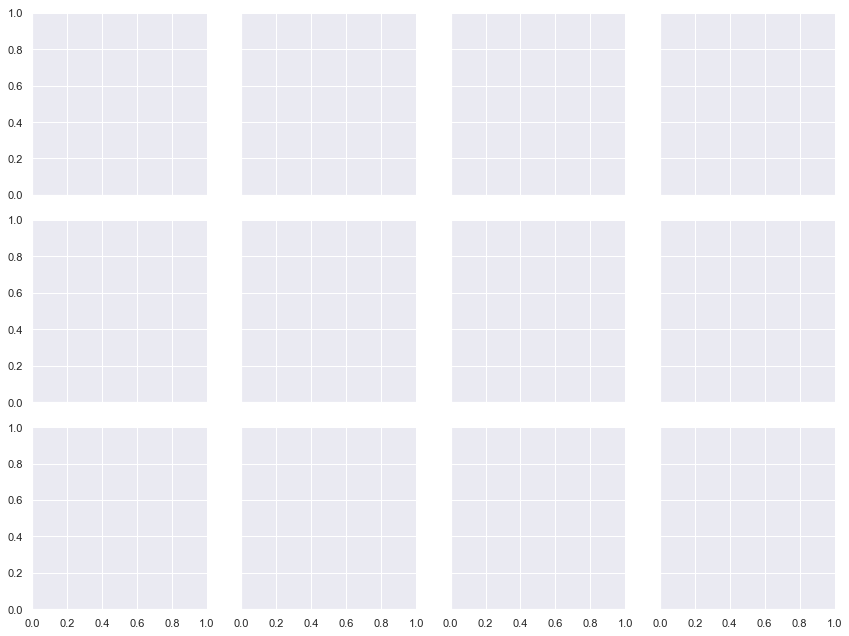

In [237]:
fig, axes = plt.subplots(nrows=3,ncols=4)
fig.subplots_adjust(hspace = .5, wspace=.001)

for ax, 



fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)

titles = ['Linear', 'Squared', 'Cubic', 'Quartic']
y_vals = [x, x * x, x**3, x**4]

# axes.flat returns the set of axes as a flat (1D) array instead
# of the two-dimensional version we used earlier
for ax, title, y in zip(axes.flat, titles, y_vals):
    ax.plot(x, y)
    ax.set_title(title)
    ax.grid(True)
    
    
############


axes = axes.ravel()

for i in range(10):

    axs[i].contourf(np.random.rand(10,10),5,cmap=plt.cm.Oranges)
    axs[i].set_title(str(250+i))
    
###########

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Distributions of Iris Features')

for ax, feature, name in zip(axes.flatten(), data.data.T, data.feature_names):
    ax.hist(feature, bins=len(np.unique(data.data.T[0]))//2)
    ax.set(title=name[:-4].upper(), xlabel='cm')

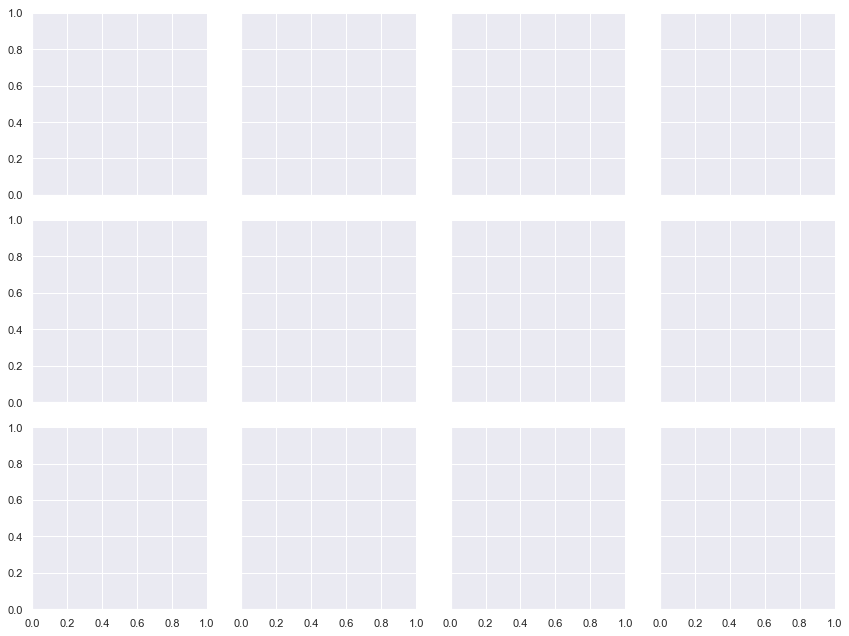

In [235]:
# Distribution of entries in popular months (summer)
fig = plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="month", data=middle_sd)
ax.set_title("Number of Point Entries in Each Popular Month from the Middle SD of points above")
plt.legend(loc='upper left')

fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True)
gdf.plot(ax=ax1, column='Value1')
gdf.plot(ax=ax2, column='Value2')

In [156]:
#Instead we can do something like this using the function we just created...
data_2009 = data_year(data, 2009)
data_2011 = data_year(data, 2011)
data_2012 = data_year(data, 2012)

KeyboardInterrupt: 

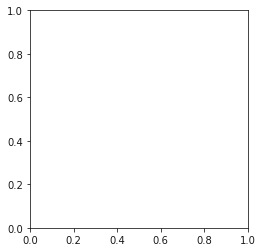

In [263]:
plots.plot()

In [59]:
data_plum = data_crop(data, 'Plum')
data_plum.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week,region,geometry_plot
1,Hula,Avney Eitan,117,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.762524 32.814104),14,6,2017,24,Golan,"POLYGON ((35.7635644170001 32.812604982, 35.76..."
19,Hula,Eliad,133,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.748809 32.789879),14,6,2017,24,Golan,"POLYGON ((35.7481829440001 32.7894588950001, 3..."
20,Hula,Eliad,133,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.748809 32.789879),14,6,2017,24,Golan,"POLYGON ((35.7481829440001 32.7894588950001, 3..."
29,Hula,Eliad,73,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.736585 32.799509),14,6,2017,24,Golan,"POLYGON ((35.735675702 32.800083036, 35.736979..."
35,Hula,Giv'at Yoav,251,2017-06-14,Plum,Medfly Trap Male,0.0,POINT (35.684661 32.788718),14,6,2017,24,Golan,"POLYGON ((35.685187523 32.7893013340001, 35.68..."


ValueError: max must be larger than min in range parameter.

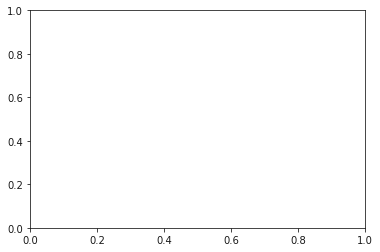

In [271]:
plt.hist(data_golan['data'].values)

In [60]:
data_apple = data_crop(data, 'Apple')
data_apple.head()

,project,grower,plot_name,report_date,crop,pest,data,geometry,day,month,year,week,region,geometry_plot
10,Hula,Avney Eitan,324,2017-06-14,Apple,Medfly Trap Male,0.0,POINT (35.798515 32.805653),14,6,2017,24,Golan,"POLYGON ((35.7975727250001 32.8064571620001, 3..."
39,Hula,Yonatan,106,2017-06-14,Apple,Medfly Trap Male,0.0,POINT (35.82859000000001 32.93983),14,6,2017,24,Golan,"POLYGON ((35.8296141640001 32.940110604, 35.82..."
40,Hula,Yonatan,109,2017-06-14,Apple,Medfly Trap Male,0.0,POINT (35.83333 32.944251),14,6,2017,24,Golan,"POLYGON ((35.833142278 32.944766433, 35.834023..."
41,Hula,Yonatan,114,2017-06-14,Apple,Medfly Trap Male,0.0,POINT (35.836524 32.941375),14,6,2017,24,Golan,"POLYGON ((35.8364117830001 32.942265176, 35.83..."
42,Hula,Yonatan,124,2017-06-14,Apple,Medfly Trap Male,0.0,POINT (35.832692 32.940632),14,6,2017,24,Golan,"POLYGON ((35.833661926 32.940033858, 35.832456..."


In [61]:
years = np.unique(data.year.values)
years

array([2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

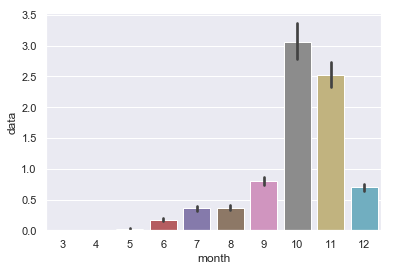

In [72]:
ax = sns.barplot(x="month", y="data", data=data_2012)

ValueError: max must be larger than min in range parameter.

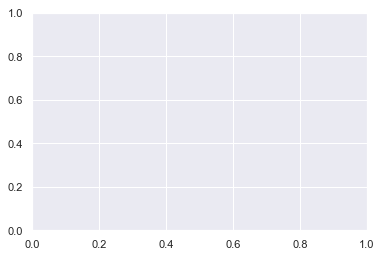

In [73]:
plt.hist(x=data_2015['data'])

In [62]:
axes = data_plum.plot.bar(rot=0, subplots=True)
axes[1].legend(loc=2)  

# same plotting code as above!
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left');

AttributeError: 'function' object has no attribute 'bar'

In [ ]:
data.groupby(['year', 'grower']).mean()

In [ ]:
fig, ax = plt.subplots(figsize = (20,16)) 


x = data_plum.report_date
y = data_plum.data
group = list(data_plum.region.value_counts().index)



# Create plot
fig, ax = plt.subplots(figsize = (20,16)) 
#ax = fig.add_subplot(1, 1, 1, axisbg="1.0")

ax.scatter(x, y, label=group)

plt.title('Matplot scatter plot')
plt.legend(loc=2)
plt.show()

In [164]:
# Years sorted by number of point entries
year_distributions = data['year'].value_counts()
year_distributions

2016    100231
2017     99746
2018     99094
2015     81755
2014     69491
2013     51809
2012     41395
2019     22758
2011      1144
2009         3
Name: year, dtype: int64

In [ ]:
data_2018.plot(column='data')

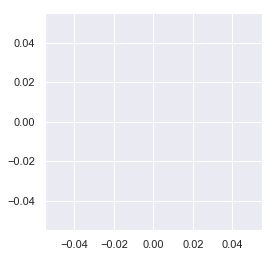

In [ ]:
plots[plots['region'] == 'Golan'].plot()

In [ ]:
data[data['region'] == 'Golan'].plot()

In [ ]:
fig, ax = plt.subplots(figsize = (20,16)) 
plots.plot(column = 'region', ax=ax)
#data.geometry.boundary.plot(color=None,edgecolor='k',linewidth = 2,ax=ax)

array([<matplotlib.axes._subplots.AxesSubplot object at 0x1a654b7dd0>,
      dtype=object)

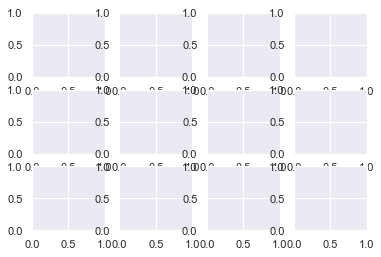

In [242]:
f, axes = plt.subplots(nrows=3, ncols=4)